# E43 — A fusão sob dependência arbitrária

Cada bloco testa certo na margem; os blocos falam entre si. Qual fusão sobrevive ao orçamento?

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import matplotlib.pyplot as plt

from frevolab import aposta

SEMENTE = 110          # <- brinque com:
BLOCOS = 107           # os blocos do capítulo
SORTES = 2000
LOTE = 100             # sortes por lote, para a dispersão
ALFA = 0.05            # o orçamento prometido
CORRELACAO = 0.5       # a estrutura entre blocos do mundo que fala

In [2]:
# Os dois mundos: mesmas marginais uniformes, estruturas diferentes.
ps_indep = aposta.ps_dependentes(SORTES, BLOCOS, 0.0, semente=SEMENTE)
ps_acopl = aposta.ps_dependentes(SORTES, BLOCOS, CORRELACAO, semente=SEMENTE + 1)
print("marginal: indep %.3f | acoplado %.3f (esperado 0,5)" % (ps_indep.mean(), ps_acopl.mean()))

marginal: indep 0.499 | acoplado 0.502 (esperado 0,5)


In [3]:
# Os três testes:
# A) Bonferroni: o mínimo dos p contra alfa/n --- válido por união, sem estrutura nenhuma;
# B) a média dos p: limiar calibrado NO MUNDO INDEPENDENTE para entregar exatamente alfa ---
#    a fusão-ingênua, que só vale com independência;
# C) a média de e-values: cada p calibrado em e-value de média um, a média dos e contra 1/alfa ---
#    válido por Markov, sem estrutura nenhuma.
media_p_indep = ps_indep.mean(axis=1)
media_p_acopl = ps_acopl.mean(axis=1)
LIMIAR_MEDIA_P = float(np.quantile(media_p_indep, ALFA))
es_indep = aposta.e_calibrado(ps_indep).mean(axis=1)
es_acopl = aposta.e_calibrado(ps_acopl).mean(axis=1)
rej = {"bonferroni_indep": (ps_indep.min(axis=1) <= ALFA / BLOCOS),
       "bonferroni_acopl": (ps_acopl.min(axis=1) <= ALFA / BLOCOS),
       "mediap_indep": (media_p_indep <= LIMIAR_MEDIA_P),
       "mediap_acopl": (media_p_acopl <= LIMIAR_MEDIA_P),
       "mediae_indep": (es_indep >= 1.0 / ALFA),
       "mediae_acopl": (es_acopl >= 1.0 / ALFA)}
taxa = {k: float(v.mean()) for k, v in rej.items()}
lote_max = {k: float(v.reshape(-1, LOTE).mean(axis=1).max()) for k, v in rej.items()}
for k in rej:
    print("%s: %.3f (pior lote %.3f)" % (k, taxa[k], lote_max[k]))
print("limiar calibrado da media de p: %.5f" % LIMIAR_MEDIA_P)

bonferroni_indep: 0.048 (pior lote 0.090)
bonferroni_acopl: 0.026 (pior lote 0.070)
mediap_indep: 0.050 (pior lote 0.090)
mediap_acopl: 0.420 (pior lote 0.590)
mediae_indep: 0.000 (pior lote 0.000)
mediae_acopl: 0.000 (pior lote 0.000)
limiar calibrado da media de p: 0.45344


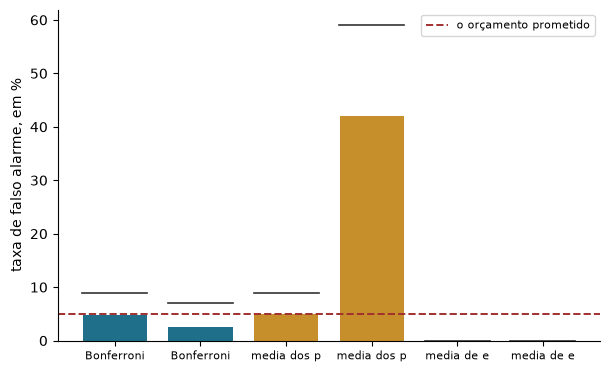

In [4]:
# Figura 1: as seis taxas contra o orçamento prometido.
ordem = ["bonferroni_indep", "bonferroni_acopl", "mediap_indep", "mediap_acopl",
         "mediae_indep", "mediae_acopl"]
rotulos = ["Bonferroni", "", "media dos p", "", "media de e", ""]
cores = ["#1f6f8b", "#1f6f8b", "#c78f2c", "#c78f2c", "#4a7c4f", "#4a7c4f"]
fig, ax = plt.subplots(figsize=(7.0, 4.3))
for i, k in enumerate(ordem):
    ax.bar(i, 100 * taxa[k], 0.75, color=cores[i])
    ax.plot([i - 0.38, i + 0.38], [100 * lote_max[k]] * 2, color="#333333", lw=1.2)
ax.axhline(100 * ALFA, color="#a13030", ls="--", lw=1.4, label="o orçamento prometido")
ax.set_xticks(range(6))
ax.set_xticklabels(["Bonferroni", "Bonferroni", "media dos p", "media dos p", "media de e", "media de e"], fontsize=8)
ax.set_ylabel("taxa de falso alarme, em %")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
from frevolab import graficos
graficos.salvar(fig, "E43_fusao", 1)
plt.show()

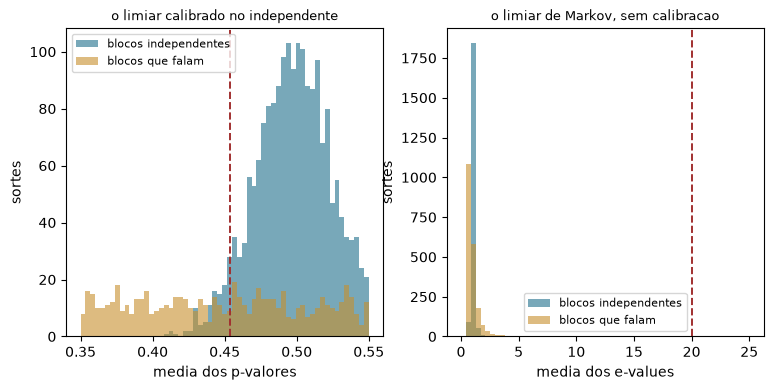

In [5]:
# Figura 2: por que a média dos p rompe e a de e-values não --- os dois mundos lado a lado.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 4.0))
bins_p = np.linspace(0.35, 0.55, 60)
ax1.hist(media_p_indep, bins=bins_p, color="#1f6f8b", alpha=0.6, label="blocos independentes")
ax1.hist(media_p_acopl, bins=bins_p, color="#c78f2c", alpha=0.6, label="blocos que falam")
ax1.axvline(LIMIAR_MEDIA_P, color="#a13030", ls="--", lw=1.4)
ax1.set_xlabel("media dos p-valores")
ax1.set_ylabel("sortes")
ax1.legend(fontsize=8)
ax1.set_title("o limiar calibrado no independente", fontsize=9)
bins_e = np.linspace(0, 25, 60)
ax2.hist(es_indep, bins=bins_e, color="#1f6f8b", alpha=0.6, label="blocos independentes")
ax2.hist(es_acopl, bins=bins_e, color="#c78f2c", alpha=0.6, label="blocos que falam")
ax2.axvline(1.0 / ALFA, color="#a13030", ls="--", lw=1.4)
ax2.set_xlabel("media dos e-values")
ax2.set_ylabel("sortes")
ax2.legend(fontsize=8)
ax2.set_title("o limiar de Markov, sem calibracao", fontsize=9)
from frevolab import graficos
graficos.salvar(fig, "E43_fusao", 2)
plt.show()

In [6]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) na figura 1, as barras da media dos p passam da linha no mundo que fala; as de Bonferroni e
#    da media de e ficam abaixo dela nos dois mundos; o traço do pior lote acompanha a barra;
# 2) na figura 2, a esquerda: o mundo que fala e mais largo e a massa a esquerda do limiar cresce;
#    a direita: as duas distribuicoes ficam bem abaixo do limiar vermelho.

In [7]:
# O que sai do laboratório e o que o livro cita.
pc = lambda k: round(100 * taxa[k], 1)
pcm = lambda k: round(100 * lote_max[k], 1)
resultado = {"fusao_bonferroni_indep": pc("bonferroni_indep"),
             "fusao_bonferroni_indep_max": pcm("bonferroni_indep"),
             "fusao_bonferroni_acoplado": pc("bonferroni_acopl"),
             "fusao_bonferroni_acoplado_max": pcm("bonferroni_acopl"),
             "fusao_mediap_indep": pc("mediap_indep"),
             "fusao_mediap_indep_max": pcm("mediap_indep"),
             "fusao_mediap_acoplado": pc("mediap_acopl"),
             "fusao_mediap_acoplado_max": pcm("mediap_acopl"),
             "fusao_mediae_indep": pc("mediae_indep"),
             "fusao_mediae_indep_max": pcm("mediae_indep"),
             "fusao_mediae_acoplado": pc("mediae_acopl"),
             "fusao_mediae_acoplado_max": pcm("mediae_acopl"),
             "fusao_mediap_limiar": round(LIMIAR_MEDIA_P, 4),
             "fusao_marginal_indep": round(float(ps_indep.mean()), 3),
             "fusao_marginal_acoplado": round(float(ps_acopl.mean()), 3),
             "fusao_correlacao": CORRELACAO,
             "fusao_sortes": SORTES}

import json
from pathlib import Path
caminho = Path("lab/resultados/E43_fusao.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "fusao_bonferroni_acoplado": 2.6,
 "fusao_bonferroni_acoplado_max": 7.0,
 "fusao_bonferroni_indep": 4.8,
 "fusao_bonferroni_indep_max": 9.0,
 "fusao_correlacao": 0.5,
 "fusao_marginal_acoplado": 0.502,
 "fusao_marginal_indep": 0.499,
 "fusao_mediae_acoplado": 0.0,
 "fusao_mediae_acoplado_max": 0.0,
 "fusao_mediae_indep": 0.0,
 "fusao_mediae_indep_max": 0.0,
 "fusao_mediap_acoplado": 42.0,
 "fusao_mediap_acoplado_max": 59.0,
 "fusao_mediap_indep": 5.0,
 "fusao_mediap_indep_max": 9.0,
 "fusao_mediap_limiar": 0.4534,
 "fusao_sortes": 2000
}
